In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/14
    print("準備完了！このまま下のセルを実行できます。")

# 第14章 サンプリング (Sampling)
## 14.1 基本サンプリング法 (Basic Sampling Algorithms)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第14章「サンプリング」第1節「基本サンプリング法」に対応する完全な解説・数式導出・図版再現・Python実装です。

---

### 本節の構成と小節一覧
- **14.1.1 期待値 (Expectations)**: モンテカルロ積分、不偏性、分散と標本誤差の次元独立性（式 14.1 〜 14.3, Figure 14.1）
- **14.1.2 標準分布 (Standard distributions)**: 逆関数法（累積分布関数の反転）、Box-Muller法、単位円盤の一様サンプリング（式 14.4 〜 14.8, Figure 14.2, 14.3）
- **14.1.3 棄却サンプリング (Rejection sampling)**: 未正規化確率密度、提案分布と上界定数 $k$、受理確率、ガンマ分布および正規分布のサンプリング（式 14.9 〜 14.10, Figure 14.4, 14.5, 14.7）
- **14.1.4 適応的棄却サンプリング (Adaptive rejection sampling: ARS)**: 対数凹分布、接線包絡線、区分的指数提案分布（Figure 14.6）
- **14.1.5 重点サンプリング (Importance sampling)**: 重点重み、非正規化比率推定量、有効サンプルサイズ (ESS)（式 14.11 〜 14.13, Figure 14.8）
- **14.1.6 重点リサンプリング (Sampling-importance-resampling: SIR)**: 候補点生成、重み付きブートストラップリサンプリング（式 14.14）


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# リポジトリルートを検索パスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "14" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.basic_sampling import (
    monte_carlo_expectation,
    convergence_analysis,
    inverse_cdf_sample_exponential,
    inverse_cdf_sample_cauchy,
    box_muller_transform,
    rejection_sample_unit_disk,
    RejectionSampler,
    rejection_sample_gamma,
    rejection_sample_gaussian_cauchy,
    AdaptiveRejectionSampler,
    compute_effective_sample_size,
    importance_sampling,
    sampling_importance_resampling,
    generate_figure_14_1,
    generate_figure_14_2,
    generate_figure_14_3,
    generate_figure_14_4,
    generate_figure_14_5,
    generate_figure_14_6,
    generate_figure_14_7,
    generate_figure_14_8,
)

setup_style()
print("Setup complete. Section 14.1 Basic Sampling module loaded successfully.")


Setup complete. Section 14.1 Basic Sampling module loaded successfully.


---

### 14.1.1 期待値 (Expectations)

深層学習およびベイズ統計学における多くの重要問題（ベイズ予測分布、周辺尤度、変分下界の評価など）は、ある確率分布 $p(z)$ のもとでの関数 $f(z)$ の期待値の計算に帰着されます：
$$
\mathbb{E}[f] = \int f(z) p(z) \, dz \tag{14.1}
$$

解析的にこの積分を求めることが不可能な場合、$p(z)$ から独立に抽出された $L$ 個のサンプル $\{z^{(l)}\}_{l=1}^L$ を用いて、モンテカルロ推定量（Monte Carlo estimator）を構築します：
$$
\widehat{f} = \frac{1}{L} \sum_{l=1}^L f(z^{(l)}) \tag{14.2}
$$

#### 1. 不偏性 (Unbiasedness)
期待値の線形性より、推定量の期待値は真の期待値に厳密に一致します：
$$
\mathbb{E}[\widehat{f}] = \frac{1}{L} \sum_{l=1}^L \mathbb{E}[f(z^{(l)})] = \frac{1}{L} \sum_{l=1}^L \mathbb{E}[f] = \mathbb{E}[f]
$$

#### 2. 分散と次元独立性 (Variance & Dimension Independence)
サンプルが独立同分布（i.i.d.）であるため、推定量の分散は各サンプルの分散の $1/L$ となります：
$$
\text{Var}[\widehat{f}] = \frac{1}{L^2} \sum_{l=1}^L \text{Var}[f(z^{(l)})] = \frac{1}{L} \text{Var}[f] = \frac{1}{L} \mathbb{E}\left[(f - \mathbb{E}[f])^2\right] \tag{14.3}
$$
推定量 $\widehat{f}$ の標準誤差（Standard Error）は $\sigma_f / \sqrt{L}$ であり、**サンプル空間 $z$ の次元数 $D$ に直接依存しない**という極めて強力な性質を持ちます。この性質により、高次元空間における積分計算においてモンテカルロ法はグリッド数値積分法（$O(N^D)$ の計算爆発）に対して圧倒的な優位性を誇ります。

#### Figure 14.1: 確率密度 $p(z)$ のもとでの期待値
確率密度 $p(z)$ が大きい領域において、関数 $f(z)$ の値が期待値計算に支配的な寄与を与えます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_1_expectation.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_1_expectation.png


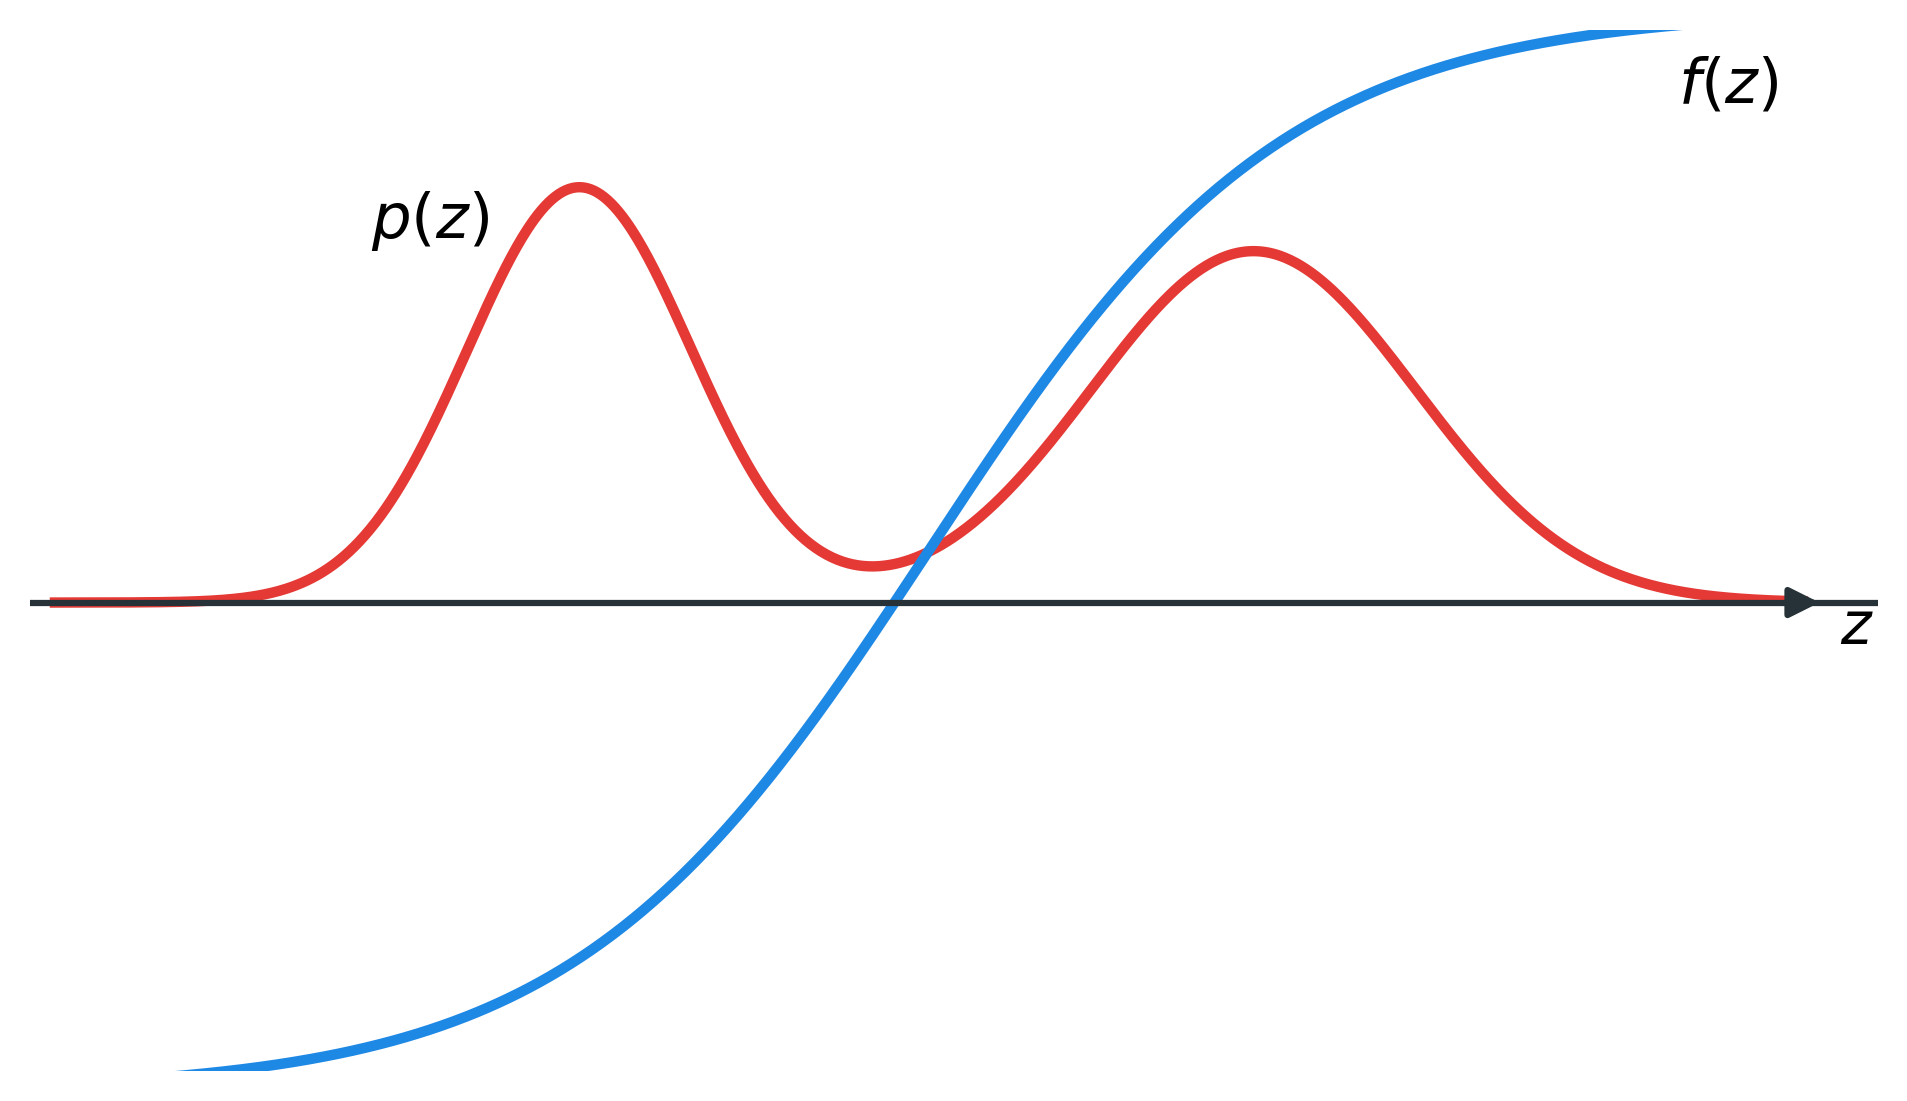

真値 E[z^2]: 1.0
モンテカルロ推定量 \hat{f}: 1.00684
推定量の標準誤差: 0.01433
95% 信頼区間: [0.97875, 1.03493]


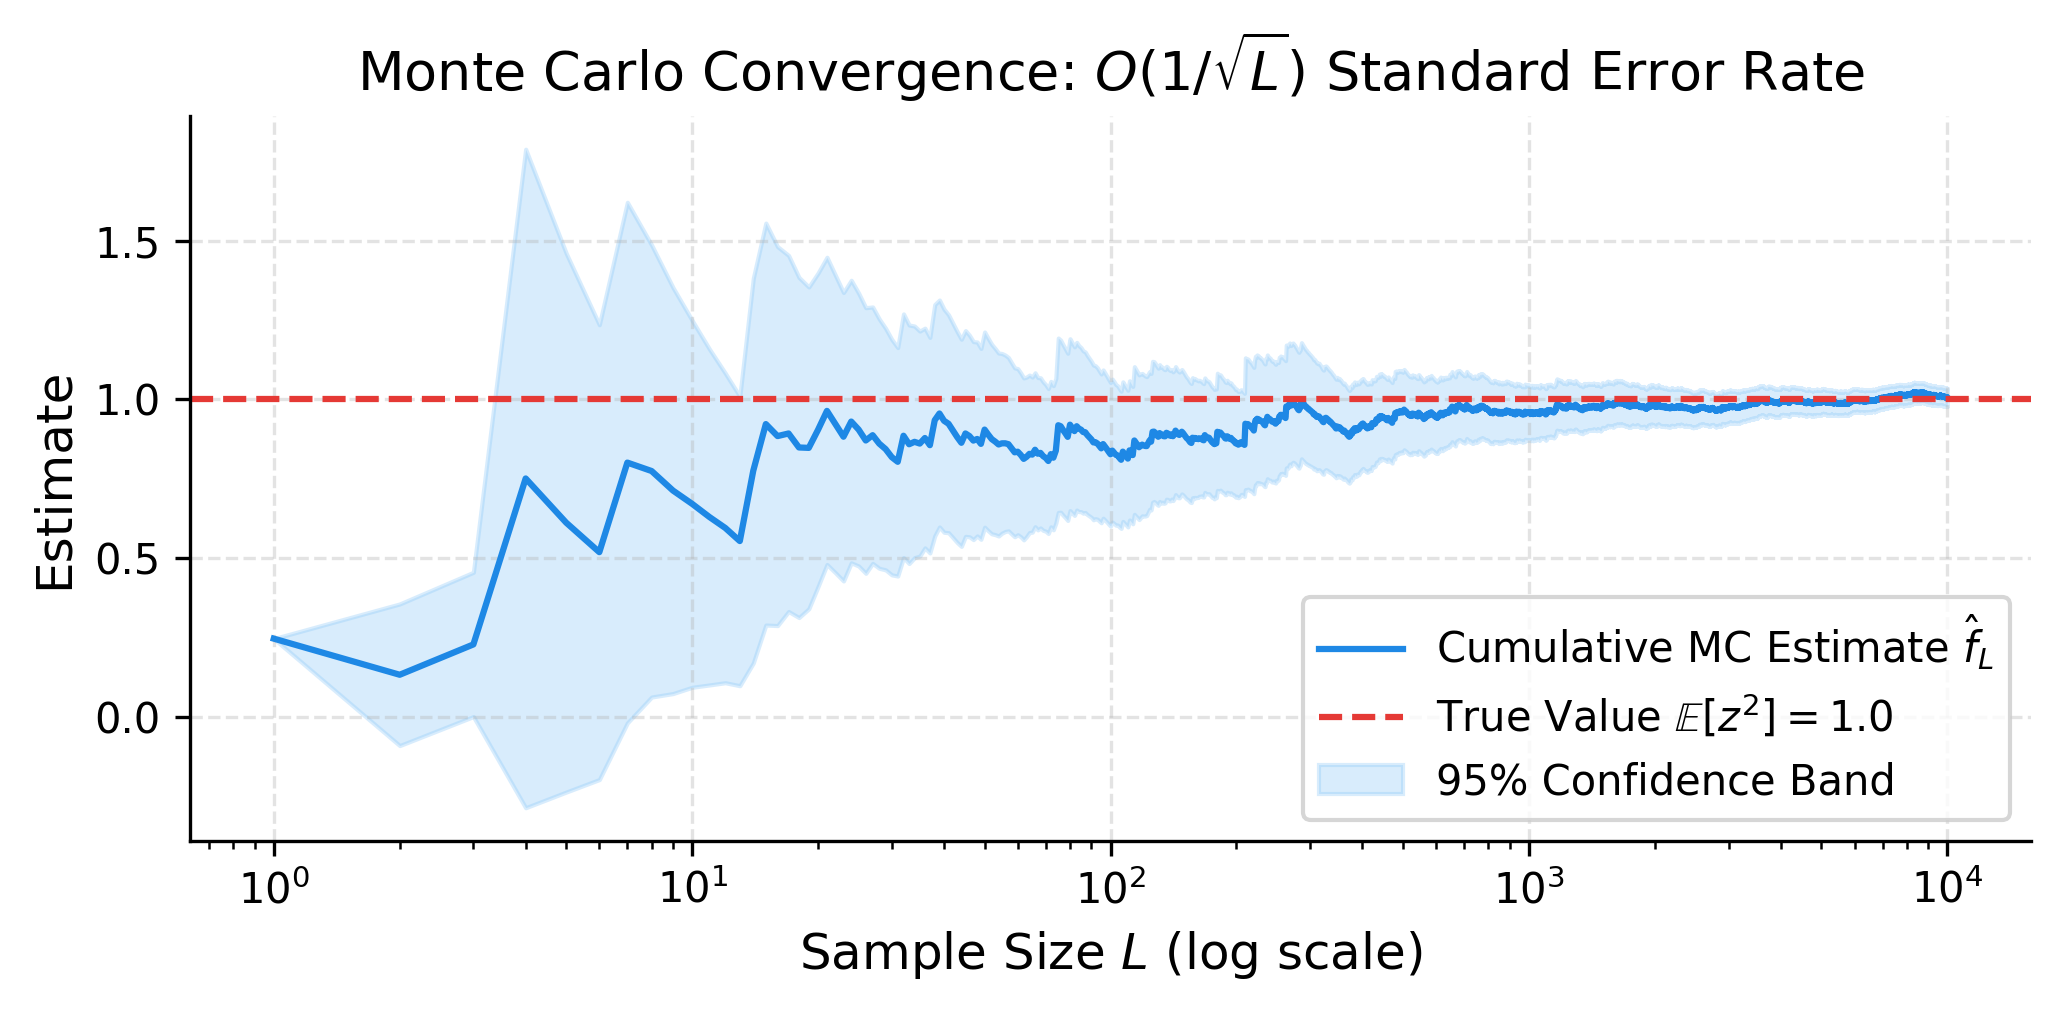

In [2]:
# Figure 14.1 再現
fig14_1 = generate_figure_14_1()
plt.show()

# モンテカルロ推定と収束性の数値シミュレーション
# 真値: E[z^2] for z ~ N(0, 1) = 1.0
rng = np.random.RandomState(42)
true_samples = rng.randn(10000)
f_func = lambda z: z ** 2

mc_res = monte_carlo_expectation(f_func, true_samples)
print(f"真値 E[z^2]: 1.0")
print(f"モンテカルロ推定量 \hat{{f}}: {mc_res['estimate']:.5f}")
print(f"推定量の標準誤差: {mc_res['std_error']:.5f}")
print(f"95% 信頼区間: [{mc_res['ci_95'][0]:.5f}, {mc_res['ci_95'][1]:.5f}]")
assert mc_res['ci_95'][0] <= 1.0 <= mc_res['ci_95'][1], "Confidence interval check failed!"

# 1/sqrt(L) 収束率の可視化
running_mean, running_std_err, steps = convergence_analysis(f_func, true_samples)

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=300)
ax.plot(steps, running_mean, color="#1e88e5", linewidth=1.5, label="Cumulative MC Estimate $\\hat{f}_L$")
ax.axhline(1.0, color="#e53935", linestyle="--", linewidth=1.5, label="True Value $\\mathbb{E}[z^2] = 1.0$")
ax.fill_between(
    steps,
    running_mean - 1.96 * running_std_err,
    running_mean + 1.96 * running_std_err,
    color="#90caf9",
    alpha=0.35,
    label="95% Confidence Band",
)
ax.set_xscale("log")
ax.set_xlabel("Sample Size $L$ (log scale)")
ax.set_ylabel("Estimate")
ax.set_title("Monte Carlo Convergence: $O(1/\\sqrt{L})$ Standard Error Rate")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


---

### 14.1.2 標準分布からのサンプリング (Standard distributions)

コンピュータの疑似乱数生成器（PRNG）は通常、区間 $(0, 1)$ 上の一様分布 $z \sim \mathcal{U}(0, 1)$ を生成します。任意の確率分布からサンプルを生成するため、以下の基本技法が用いられます。

#### 1. 逆関数法（Transformation / Inversion Method）
確率変数 $z \sim \mathcal{U}(0, 1)$（確率密度 $p(z) = 1$）に対し、単調増加な変換 $y = h^{-1}(z) \iff z = h(y)$ を施すと、変数変換公式より：
$$
p(y) = p(z) \left| \frac{dz}{dy} \right| = \frac{dh(y)}{dy} \tag{14.4}
$$
両辺を積分すると、変換関数 $h(y)$ は目的分布の累積分布関数（CDF）に一致します：
$$
z = h(y) = \int_{-\infty}^y p(y') \, dy' = F(y) \tag{14.5}
$$
したがって、目的分布の累積分布関数の逆関数 $F^{-1}$ が解析的に求まる場合、$z \sim \mathcal{U}(0, 1)$ を生成して $y = F^{-1}(z)$ を計算することで、$p(y)$ からの厳密なサンプリングが可能です。

- **指数分布 $\text{Exp}(\lambda)$**:
  $$
  F(y) = 1 - e^{-\lambda y} = z \implies y = -\frac{1}{\lambda} \ln(1 - z) \tag{14.6}
  $$
- **コーシー分布 $\text{Cauchy}(x_0, \gamma)$**:
  $$
  F(y) = \frac{1}{2} + \frac{1}{\pi} \arctan\left(\frac{y - x_0}{\gamma}\right) = z \implies y = x_0 + \gamma \tan\left(\pi\left(z - \frac{1}{2}\right)\right)
  $$

#### Figure 14.2: 逆関数法の幾何学的関係
累積分布関数 $h(y)$ が区間 $[0, 1]$ を $y$ 軸全体に全単射で写像します。

#### 2. Box-Muller 変換（正規分布の生成）
標準正規分布のCDFは誤差関数（erf）を含み解析的逆関数を持ちません。Box-Muller法は、2次元空間の極座標変換 $(r, \theta)$ を利用して2つの独立な一様乱数 $u_1, u_2 \sim \mathcal{U}(0, 1)$ から2つの独立な標準正規乱数を生成します：
$$
z_1 = \sqrt{-2 \ln u_1} \cos(2\pi u_2) \tag{14.7}
$$
$$
z_2 = \sqrt{-2 \ln u_1} \sin(2\pi u_2) \tag{14.8}
$$

#### 3. 単位円盤上の幾何学的サンプリング（Figure 14.3）
正方形 $[-1, 1] \times [-1, 1]$ 内の一様乱数 $(z_1, z_2)$ を生成し、単位円盤 $z_1^2 + z_2^2 \le 1$ の内部にある点のみを受理します。
受理確率は円と外接正方形の面積比：
$$
p(\text{accept}) = \frac{\pi \times 1^2}{2 \times 2} = \frac{\pi}{4} \approx 0.7854
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_2_transformation_method.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_2_transformation_method.png


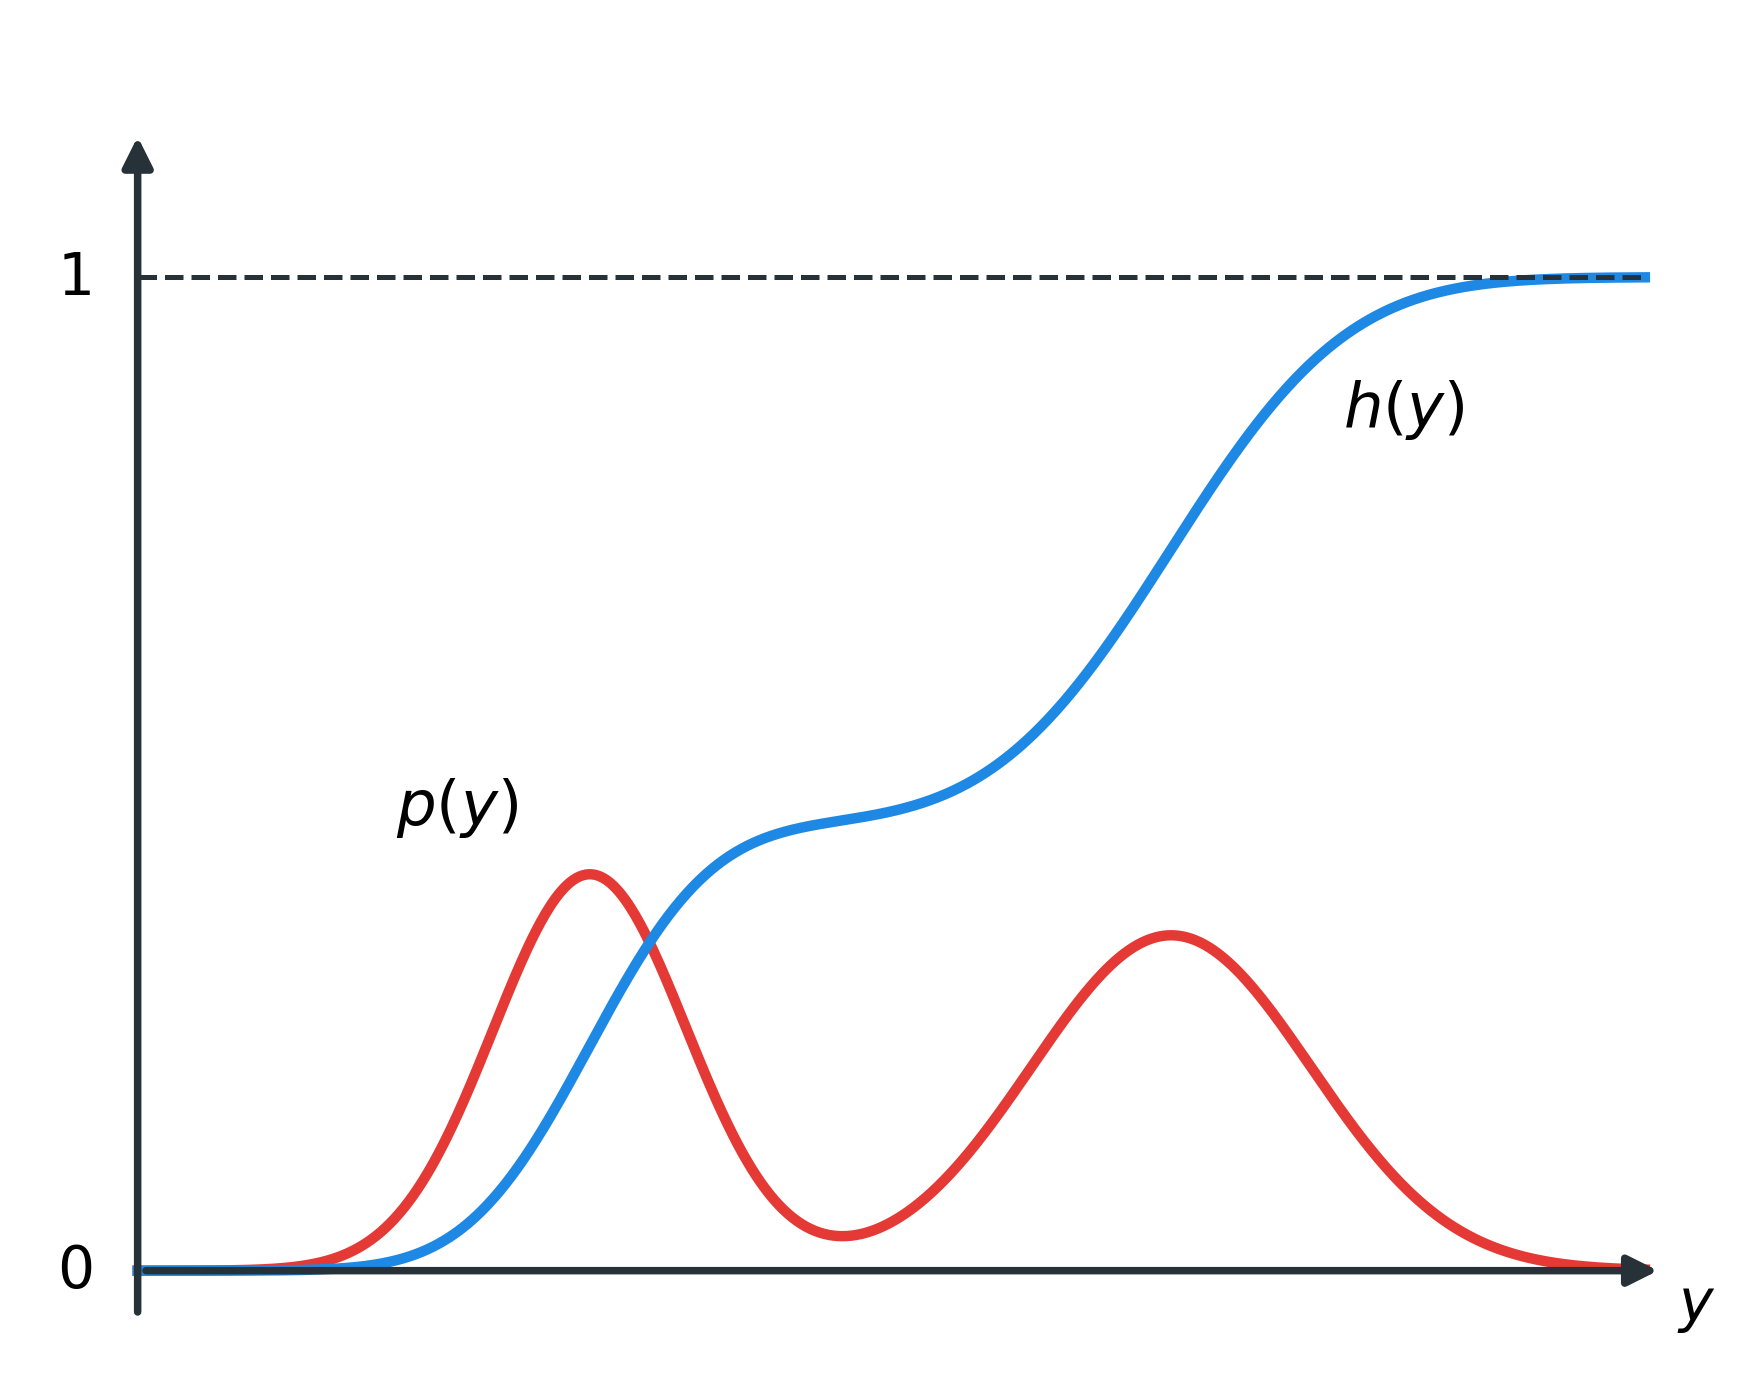

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_3_unit_disk_sampling.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_3_unit_disk_sampling.png


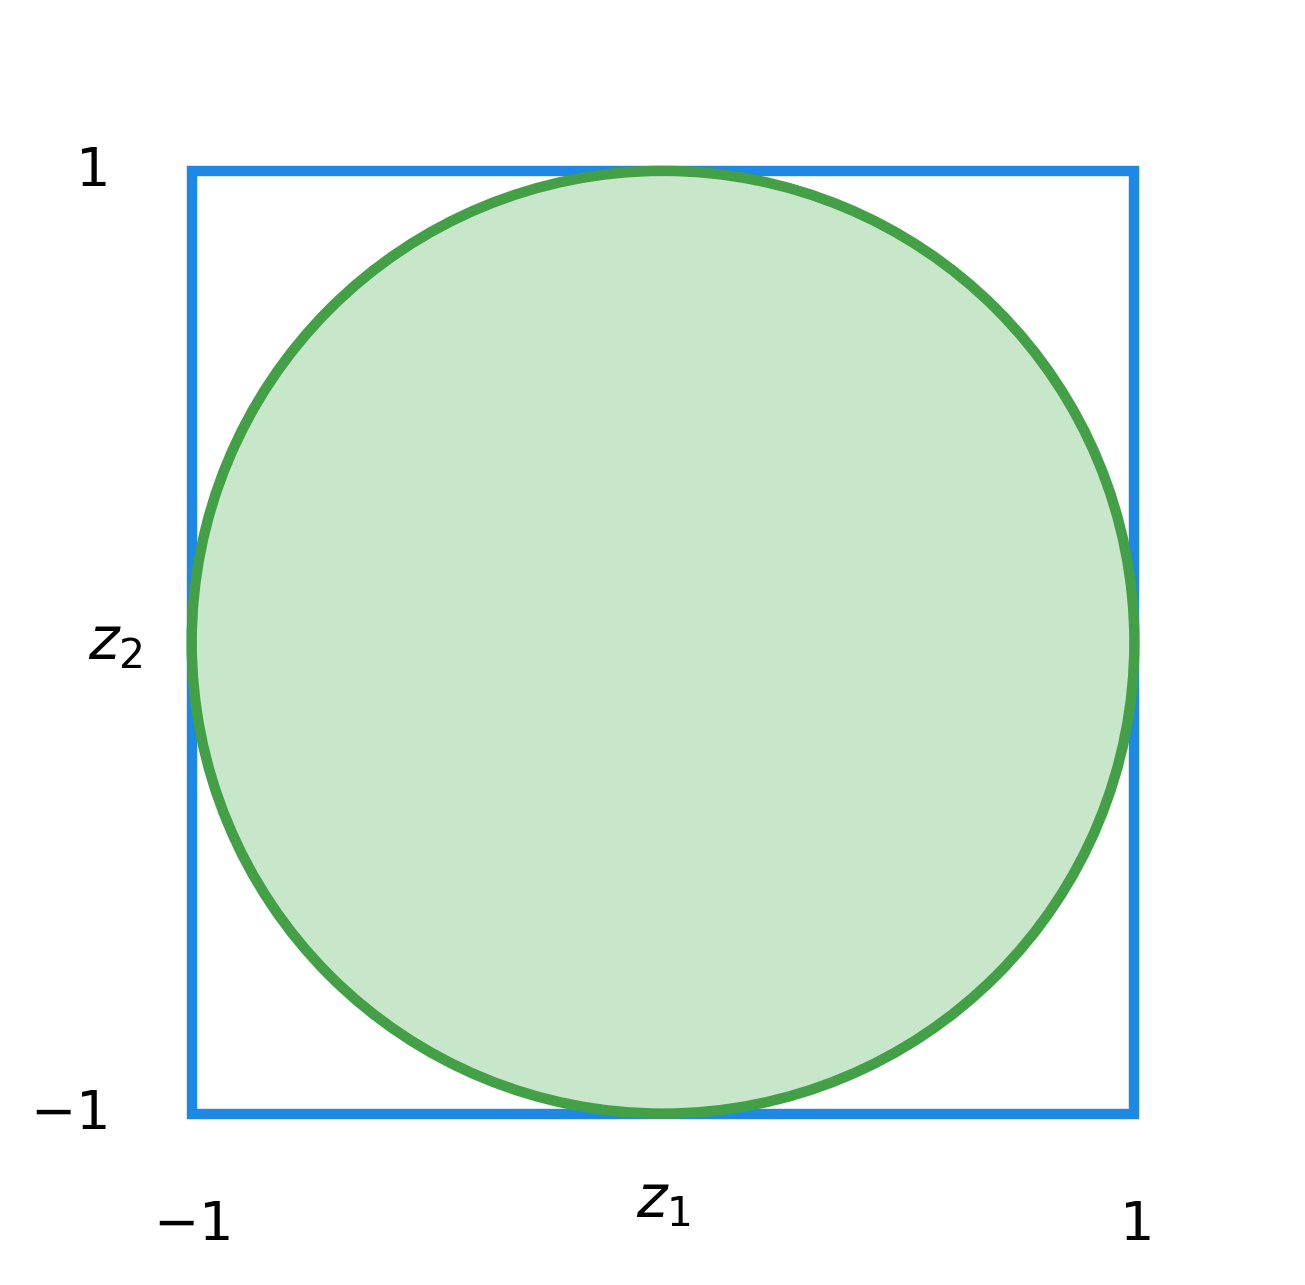

指数分布サンプル平均: 0.6517 (理論値 1/1.5 = 0.6667)
Box-Muller z1 平均/分散: 0.0029, 1.0316
Box-Muller z2 平均/分散: -0.0113, 0.9965
円盤サンプリング受理率: 0.7894 (理論値 pi/4 = 0.7854)


In [3]:
# Figures 14.2 & 14.3 再現
fig14_2 = generate_figure_14_2()
plt.show()

fig14_3 = generate_figure_14_3()
plt.show()

# 逆関数法とBox-Muller法の数値検証
exp_samples = inverse_cdf_sample_exponential(lam=1.5, num_samples=10000, seed=42)
cauchy_samples = inverse_cdf_sample_cauchy(x0=0.0, gamma=1.0, num_samples=10000, seed=42)
z1, z2 = box_muller_transform(num_pairs=10000, seed=42)
disk_accepted, acc_rate, _, _ = rejection_sample_unit_disk(num_samples=5000, seed=42)

print(f"指数分布サンプル平均: {np.mean(exp_samples):.4f} (理論値 1/1.5 = {1/1.5:.4f})")
print(f"Box-Muller z1 平均/分散: {np.mean(z1):.4f}, {np.var(z1):.4f}")
print(f"Box-Muller z2 平均/分散: {np.mean(z2):.4f}, {np.var(z2):.4f}")
print(f"円盤サンプリング受理率: {acc_rate:.4f} (理論値 pi/4 = {np.pi/4:.4f})")
assert abs(acc_rate - np.pi / 4.0) < 0.02, "Disk acceptance rate failed!"


---

### 14.1.3 棄却サンプリング (Rejection sampling)

目的分布 $p(z)$ が正規化定数 $Z_p$ を除いてしか評価できない場合（$p(z) = \frac{1}{Z_p} \widetilde{p}(z)$）に用いられる強力なアルゴリズムです。

#### 1. アルゴリズムと幾何学的原理 (Figure 14.4)
容易にサンプリング可能な提案分布 $q(z)$ と、すべての $z$ に対して以下を満たす定数 $k$ を選定します：
$$
k q(z) \ge \widetilde{p}(z) \quad (\forall z) \tag{14.9}
$$
サンプリング手順：
1. $z_0 \sim q(z)$ を生成。
2. $u_0 \sim \mathcal{U}(0, k q(z_0))$ を生成。
3. $u_0 \le \widetilde{p}(z_0)$ ならば $z = z_0$ を受理（Accept）。そうでなければ棄却（Reject）して繰り返す。

#### 2. 受理確率 (Acceptance Rate)
任意のサンプルが受理される総合確率は、全空間における曲線下面積の比率となります：
$$
p(\text{accept}) = \int \frac{\widetilde{p}(z)}{k q(z)} q(z) \, dz = \frac{1}{k} \int \widetilde{p}(z) \, dz = \frac{Z_p}{k} \tag{14.10}
$$
目的分布が正規化されている場合（$Z_p = 1$）、受理確率は厳密に $1/k$ となります。効率を高めるには、包絡関数 $k q(z)$ が $\widetilde{p}(z)$ にできる限り密着するよう $k$ を最小化する必要があります。

#### 3. ガンマ分布とコーシー提案分布 (Figure 14.5)
形状母数 $a > 1$ のガンマ分布 $\text{Gam}(z \mid a, b) \propto z^{a-1} e^{-b z}$ に対し、最頻値 $z = (a - 1) / b$ を中心としスケール $\gamma = \sqrt{2a - 1} / b$ を持つコーシー分布を提案分布として採用すると、裾の重いコーシー分布が指数減衰するガンマ分布を完全に包絡します。

#### 4. 正規分布とコーシー包絡分布 (Figure 14.7)
標準正規分布 $p(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}$ に対し、スケール $\gamma = \sqrt{2}$、上界定数 $k = \sqrt{\pi}$ のコーシー提案分布 $q(z) = \frac{1}{\pi \sqrt{2} (1 + z^2/2)}$ を採用すると、$z=0$ で等号 $k q(0) = p(0) = 1/\sqrt{2\pi}$ が成立し、すべての $z$ で $k q(z) \ge p(z)$ となります。受理確率は $1/\sqrt{\pi} \approx 0.5642$ です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_4_rejection_sampling.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_4_rejection_sampling.png


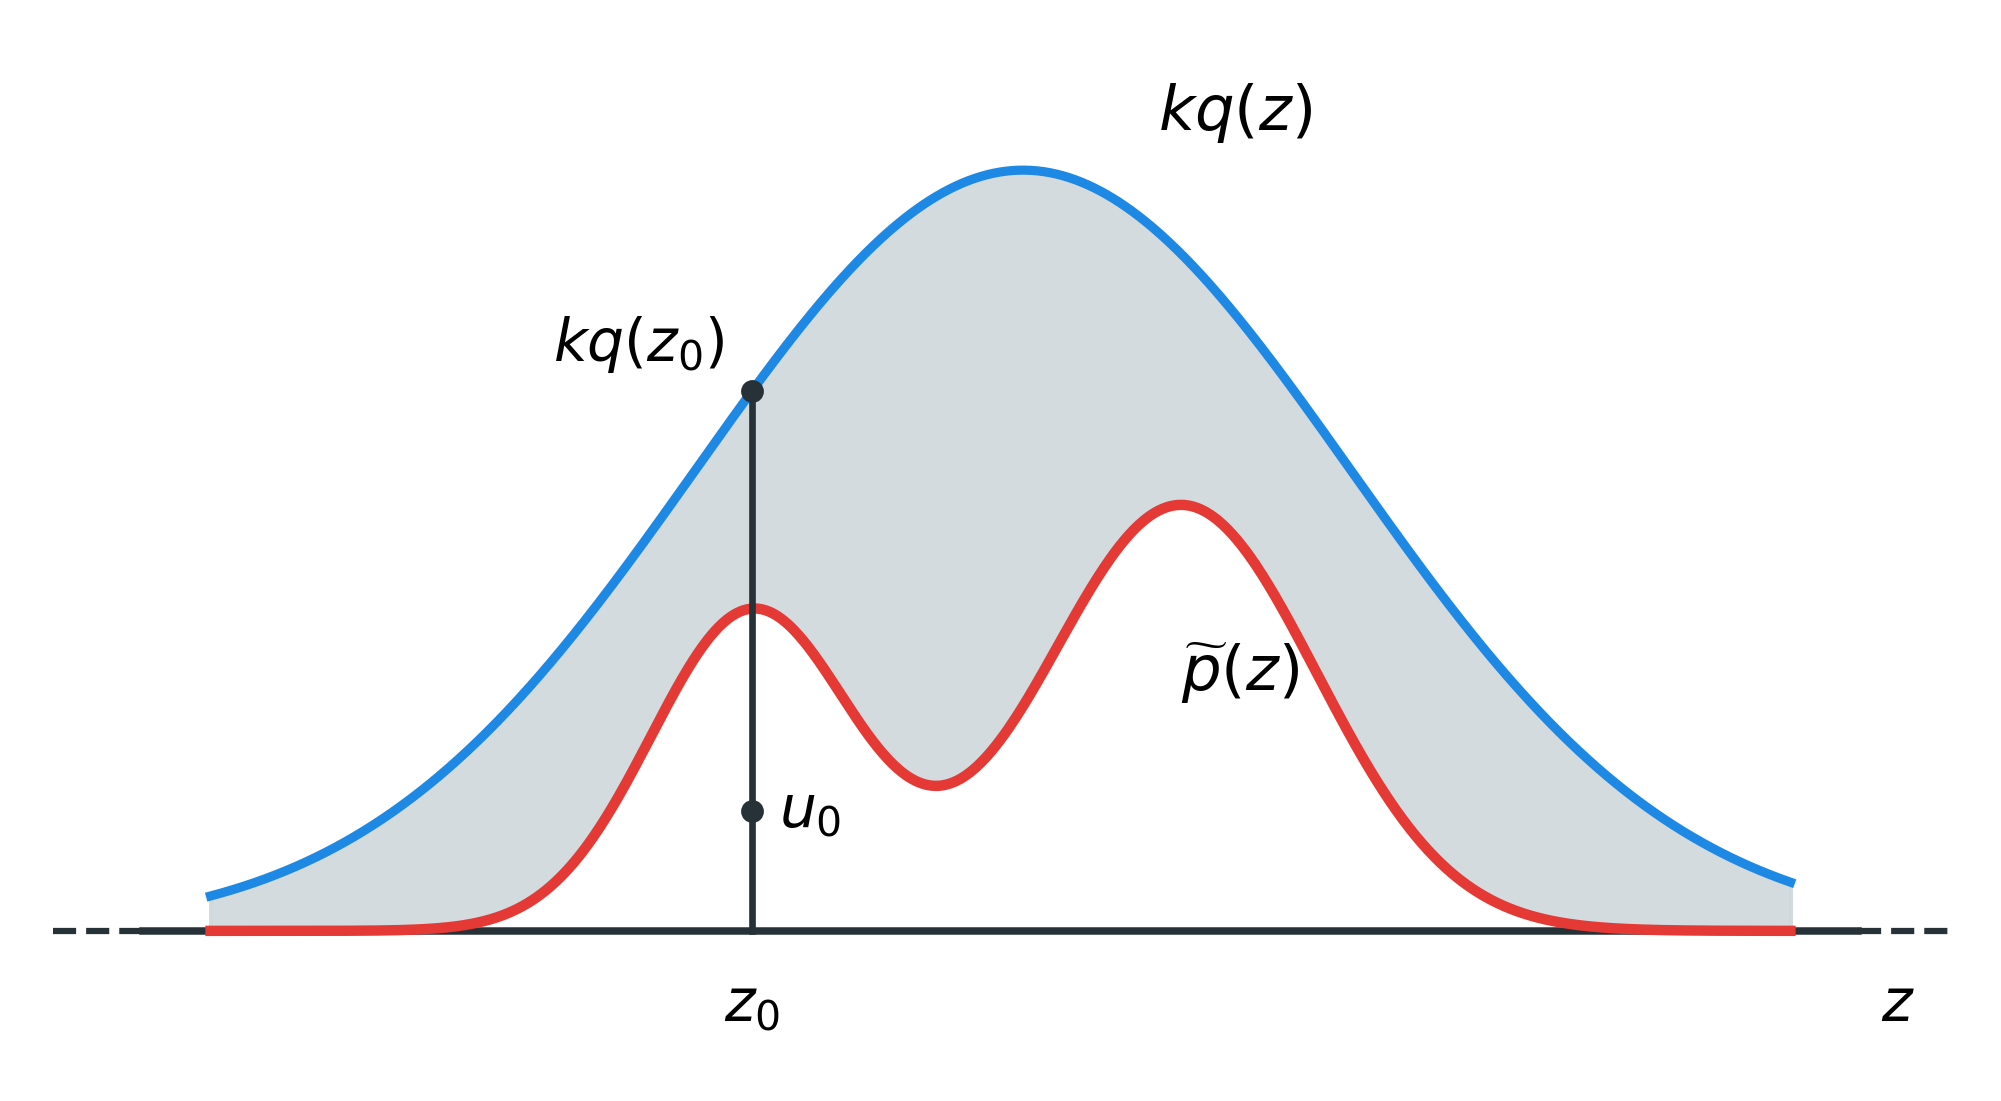

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_5_rejection_gamma.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_5_rejection_gamma.png


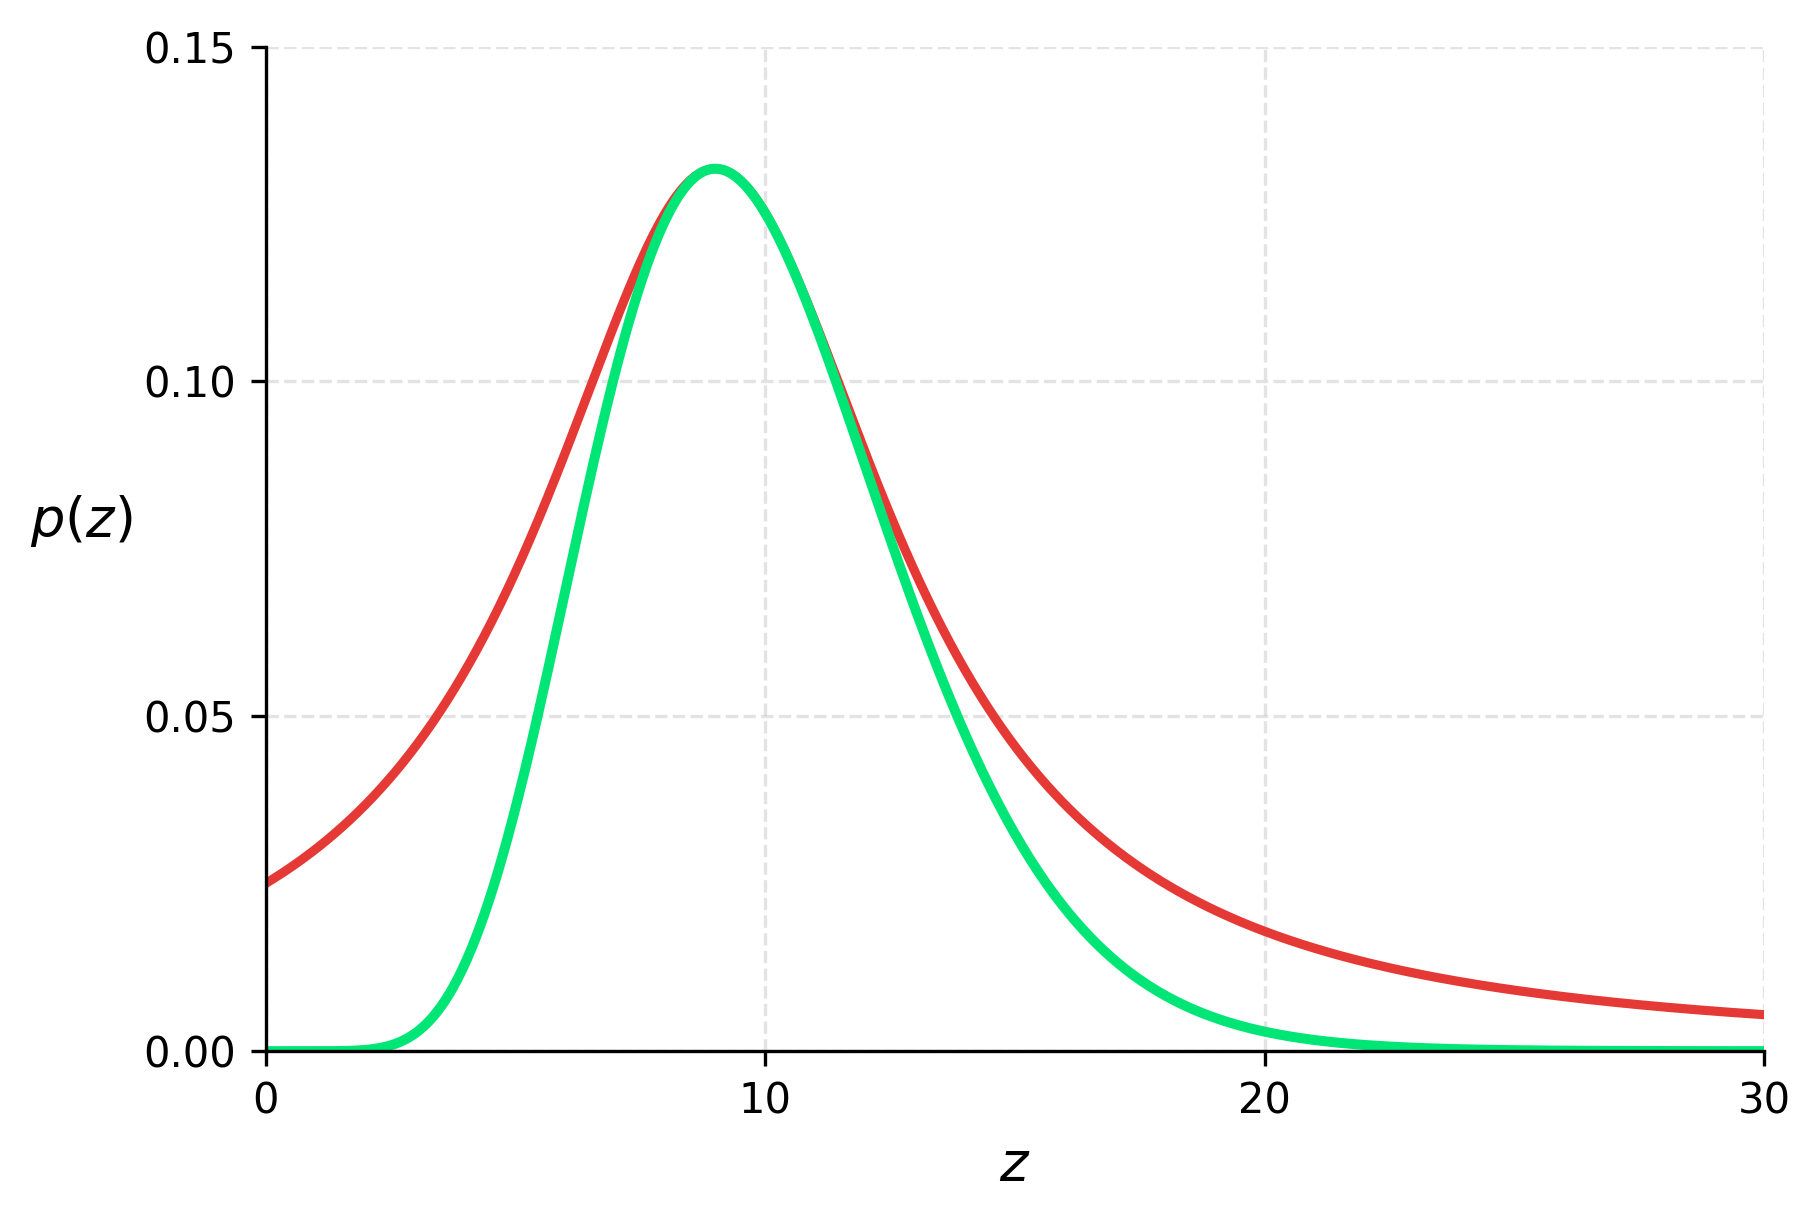

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_7_gaussian_cauchy_rejection.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_7_gaussian_cauchy_rejection.png


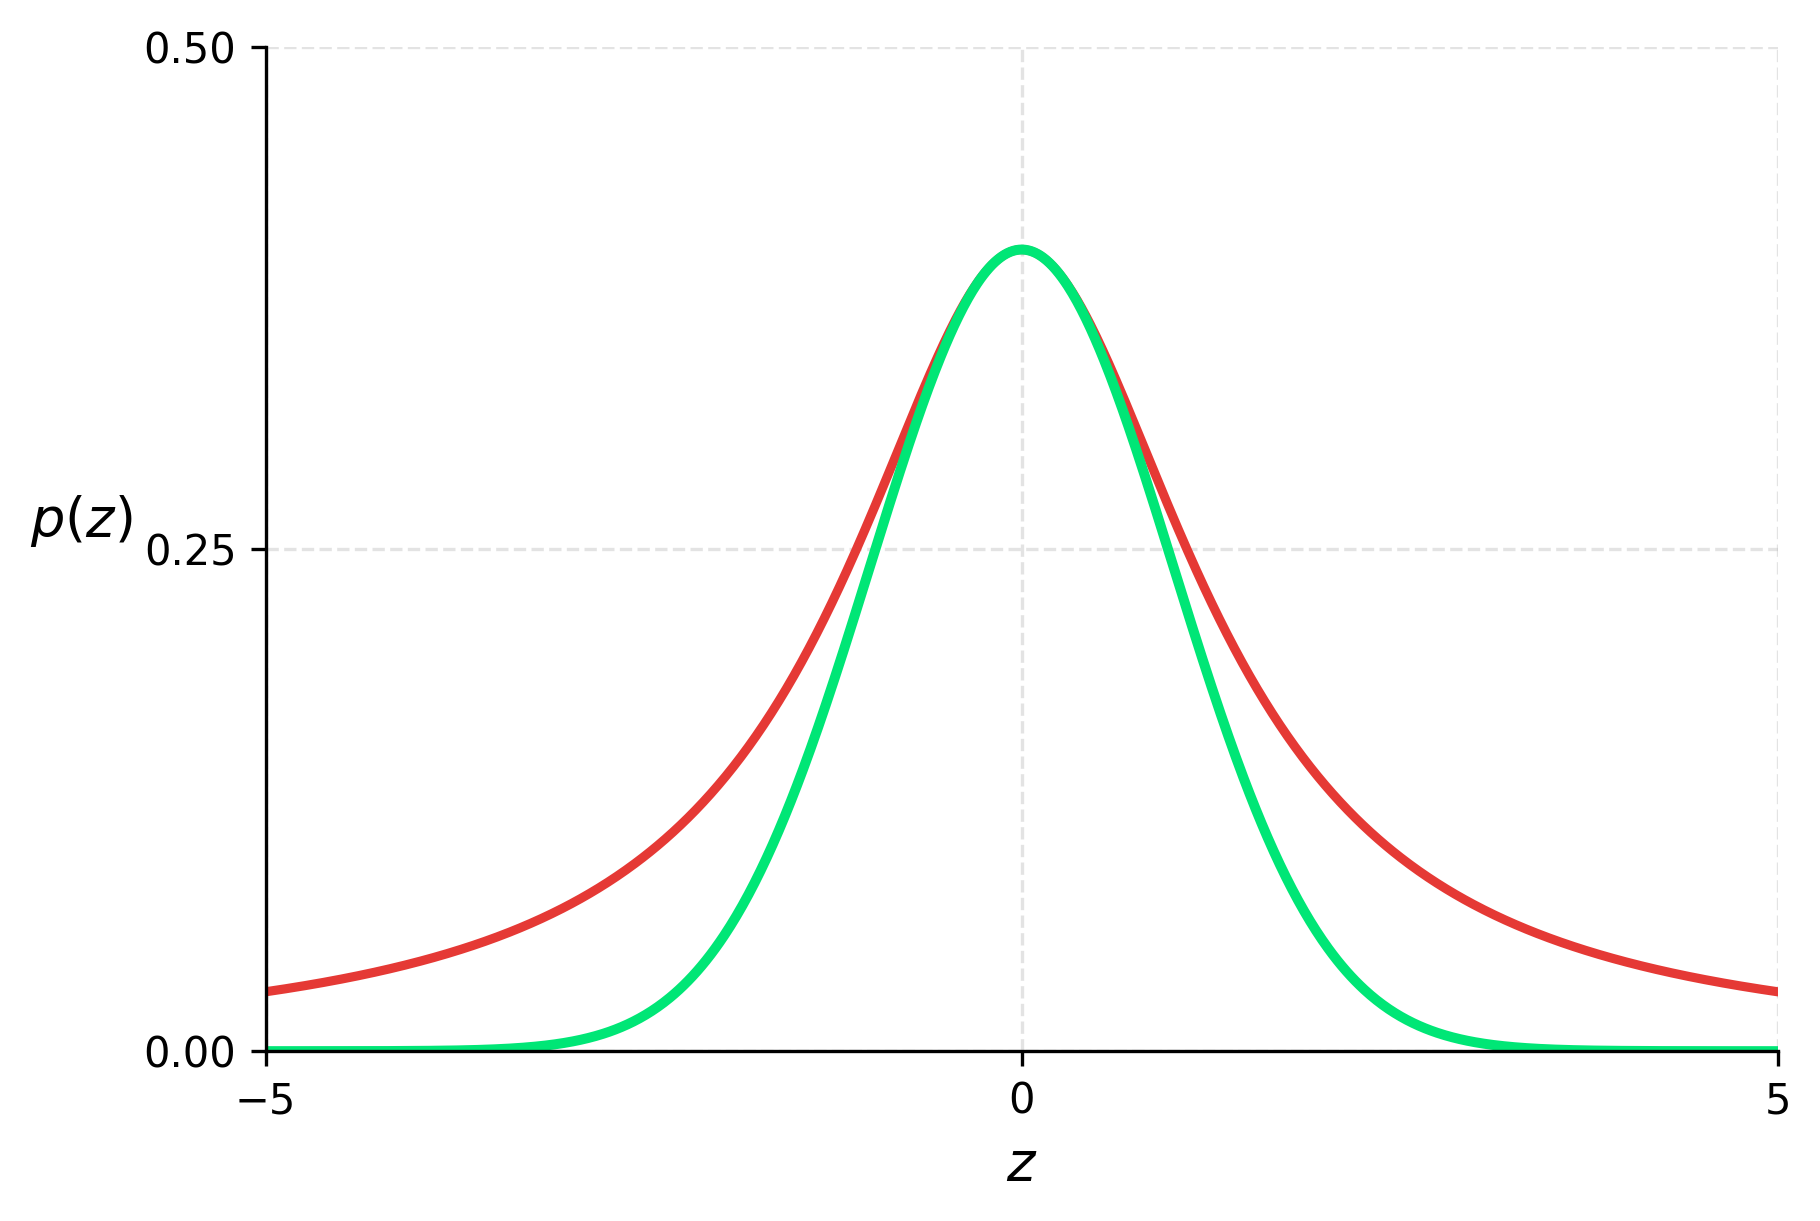

ガンマサンプリング受理率: 0.5357
正規分布(Cauchy提案) 受理率: 0.5588 (理論値 1/sqrt(pi) = 0.5642)
ガンマ分布 KS検定 p値: 0.1941


In [4]:
# Figures 14.4, 14.5, 14.7 再現
fig14_4 = generate_figure_14_4()
plt.show()

fig14_5 = generate_figure_14_5()
plt.show()

fig14_7 = generate_figure_14_7()
plt.show()

# ガンマ分布と正規分布の棄却サンプリング検証
res_gamma = rejection_sample_gamma(a=10.0, b=1.0, num_samples=3000, seed=42)
res_gauss = rejection_sample_gaussian_cauchy(num_samples=4000, seed=42)

print(f"ガンマサンプリング受理率: {res_gamma['acceptance_rate']:.4f}")
print(f"正規分布(Cauchy提案) 受理率: {res_gauss['acceptance_rate']:.4f} (理論値 1/sqrt(pi) = {1/np.sqrt(np.pi):.4f})")

# ガンマ分布サンプルの適合度検定 (KS検定)
ks_gamma = stats.kstest(res_gamma["samples"], "gamma", args=(10.0, 0, 1.0))
print(f"ガンマ分布 KS検定 p値: {ks_gamma.pvalue:.4f}")
assert ks_gamma.pvalue > 0.01, "Gamma KS test failed!"


---

### 14.1.4 適応的棄却サンプリング (Adaptive rejection sampling: ARS)

通常の棄却サンプリングでは適切な提案分布 $q(z)$ と上界定数 $k$ の選定が困難な場合があります。対数凹（log-concave）な確率分布：
$$
\frac{d^2}{dz^2} \ln \widetilde{p}(z) \le 0
$$
に対しては、**適応的棄却サンプリング (ARS: Gilks & Wild, 1992)** が極めて有効です。

#### 包絡線の幾何学的構築 (Figure 14.6)
1. 初期格子点集合 $\{z_1 < z_2 < \dots < z_K\}$ において、対数確率密度 $\ln \widetilde{p}(z)$ の接線を引きます：
   $$
   T_i(z) = \ln \widetilde{p}(z_i) + \left.\frac{d \ln \widetilde{p}}{dz}\right|_{z_i} (z - z_i) = a_i z + b_i
   $$
2. 対数凹性により、すべての接線は常に対数確率密度の上界となります：$T_i(z) \ge \ln \widetilde{p}(z)$。
3. 隣接する接線の交点 $z_{i, i+1}^* = \frac{b_{i+1} - b_i}{a_i - a_{i+1}}$ を境目として、区分的線形な対数包絡線 $\text{env}(z)$ を形成します。
4. 元の確率空間では、これは**区分的指数分布（piecewise exponential distribution）** $q(z) \propto e^{\text{env}(z)}$ となり、逆関数法により厳密かつ容易にサンプリングが可能です。
5. 提案点 $z_{\text{prop}}$ が棄却された場合、その点 $z_{\text{prop}}$ を新たな格子点として追加し、包絡線を局所的に再構築します。これによりサンプリングが進むほど包絡線が目的分布に漸近し、棄却率が自動的に低下します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_6_adaptive_rejection_sampling.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_6_adaptive_rejection_sampling.png


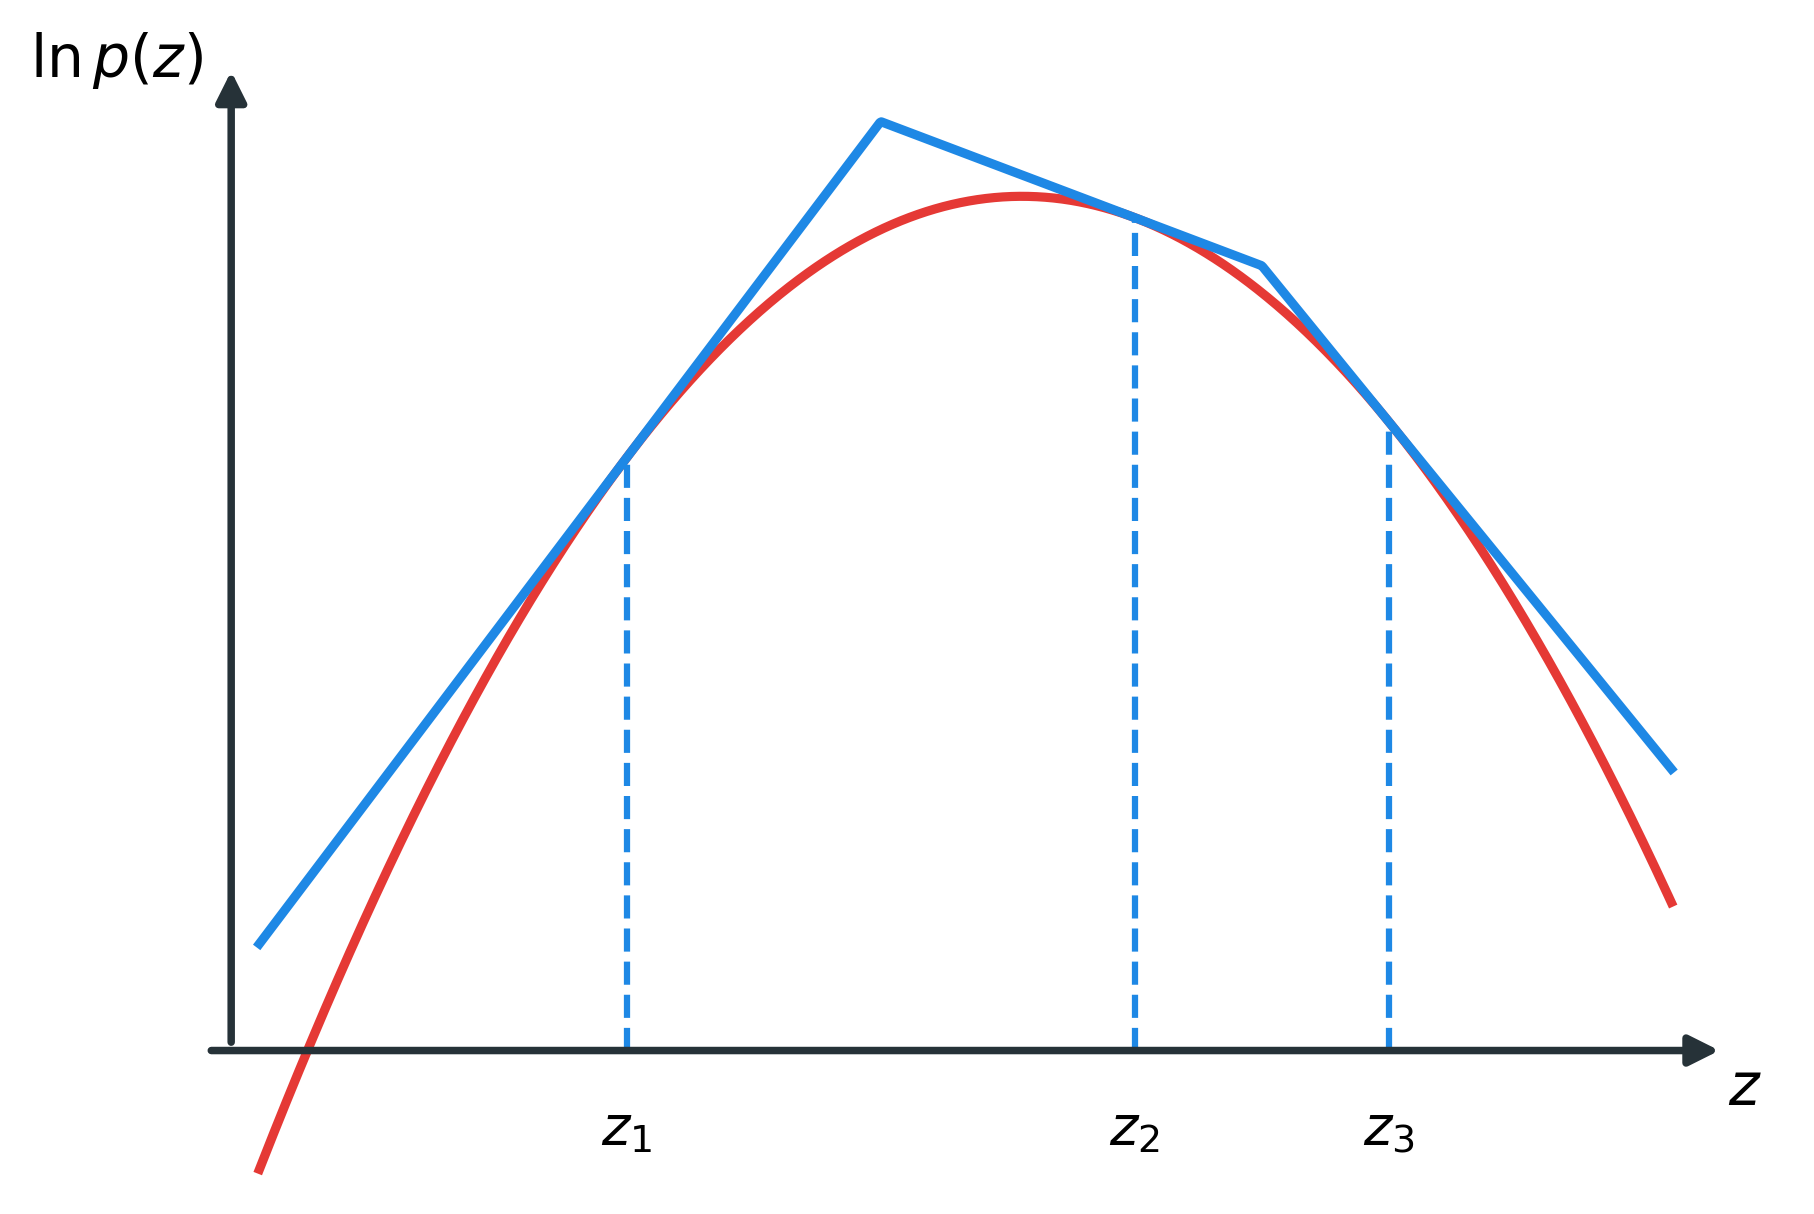

ARS サンプル平均: 0.0257 (理論値 0.0)
ARS サンプル分散: 0.9616 (理論値 1.0)
ARS KS検定 p値: 0.2015


In [5]:
# Figure 14.6 再現
fig14_6 = generate_figure_14_6()
plt.show()

# ARS の動作検証
ars = AdaptiveRejectionSampler(
    log_p_tilde=lambda z: -0.5 * z ** 2,
    d_log_p_tilde=lambda z: -z,
    initial_points=[-1.5, 0.0, 1.5],
    domain_bounds=(-4.0, 4.0),
)

ars_samples = ars.sample(num_samples=2000, seed=42)
print(f"ARS サンプル平均: {np.mean(ars_samples):.4f} (理論値 0.0)")
print(f"ARS サンプル分散: {np.var(ars_samples):.4f} (理論値 1.0)")
ks_ars = stats.kstest(ars_samples, "norm")
print(f"ARS KS検定 p値: {ks_ars.pvalue:.4f}")
assert ks_ars.pvalue > 0.01, "ARS KS test failed!"


---

### 14.1.5 重点サンプリング (Importance sampling)

目的分布 $p(z)$ から直接サンプリングすることが困難であるが、$p(z)$ の値を評価することは可能な場合、容易にサンプリングできる提案分布 $q(z)$ を導入して期待値を書き換えます：
$$
\mathbb{E}[f] = \int f(z) p(z) \, dz = \int f(z) \frac{p(z)}{q(z)} q(z) \, dz = \mathbb{E}_{q}\left[ f(z) \frac{p(z)}{q(z)} \right] \tag{14.11}
$$

ここで $w(z) = \frac{p(z)}{q(z)}$ を**重点重み (importance weight)** と呼びます。

#### 1. 未正規化比率推定量 (Ratio Estimator)
目的分布と提案分布が正規化定数を除いてしか評価できない場合（$p(z) = \widetilde{p}(z)/Z_p, q(z) = \widetilde{q}(z)/Z_q$）：
$$
\frac{Z_p}{Z_q} = \int \frac{\widetilde{p}(z)}{\widetilde{q}(z)} q(z) \, dz \approx \frac{1}{L} \sum_{l=1}^L \widetilde{w}_l, \quad \widetilde{w}_l = \frac{\widetilde{p}(z^{(l)})}{\widetilde{q}(z^{(l)})}
$$
したがって、期待値の比率推定量は正規化重み $W_l$ を用いて以下のように表されます：
$$
\widehat{f} = \frac{\sum_{l=1}^L \widetilde{w}_l f(z^{(l)})}{\sum_{l=1}^L \widetilde{w}_l} = \sum_{l=1}^L W_l f(z^{(l)}), \quad W_l = \frac{\widetilde{w}_l}{\sum_{m=1}^L \widetilde{w}_m} \tag{14.12}
$$

#### 2. 有効サンプルサイズ (Effective Sample Size: ESS)
少数のサンプルが極端に大きな重みを持つ「重みの退化」を診断するため、有効サンプルサイズが定義されます：
$$
\text{ESS} = \frac{\left(\sum_{l=1}^L \widetilde{w}_l\right)^2}{\sum_{l=1}^L \widetilde{w}_l^2} = \frac{1}{\sum_{l=1}^L W_l^2} \tag{14.13}
$$
すべての重みが均等なとき $\text{ESS} = L$ となり、単一のサンプルが全重みを独占するとき $\text{ESS} = 1$ となります。

#### Figure 14.8: 重点サンプリングの幾何学
提案分布 $q(z)$ は、$|f(z)| p(z)$ が大きな値をとる領域全体を十分に覆う（heavy-tailedである）必要があります。もし $p(z)$ の裾で $q(z) \to 0$ が $p(z)$ より速い場合、比率 $p(z)/q(z)$ が爆発して推定量の分散が無限大に発散する危険があります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_8_importance_sampling.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_8_importance_sampling.png


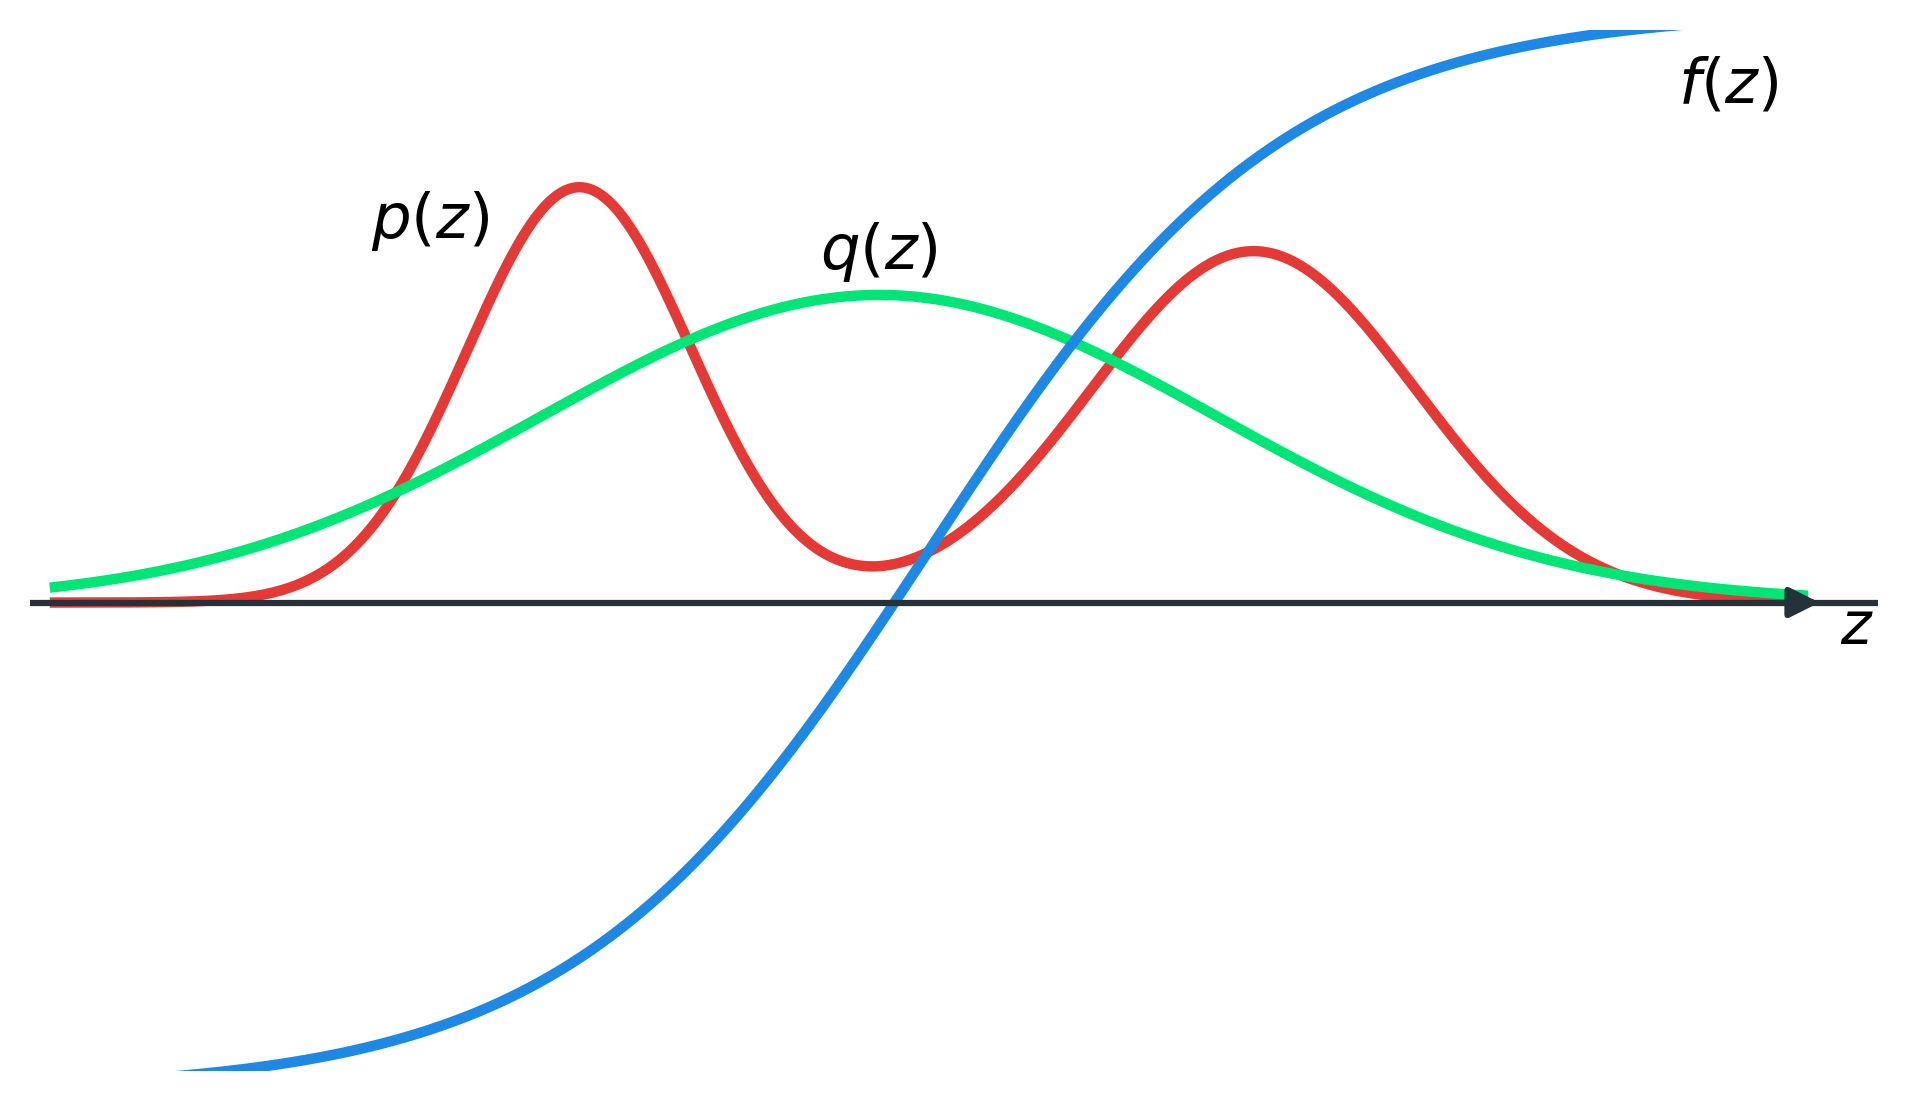

真値 E[z^2]: 2.8900
重点サンプリング推定量: 2.8754
有効サンプルサイズ (ESS): 6533.3 / 10000 (65.3%)


In [6]:
# Figure 14.8 再現
fig14_8 = generate_figure_14_8()
plt.show()

# 重点サンプリングの数値検証
# Target: N(1.5, 0.8^2), Proposal: N(1.0, 1.5^2), Integrand: f(z) = z^2
target_p = lambda z: stats.norm.pdf(z, loc=1.5, scale=0.8)
proposal_q = lambda z: stats.norm.pdf(z, loc=1.0, scale=1.5)
sample_q = lambda n, rng: rng.randn(n) * 1.5 + 1.0

is_res = importance_sampling(
    f=lambda z: z ** 2,
    target_p=target_p,
    proposal_q=proposal_q,
    sample_q=sample_q,
    num_samples=10000,
    is_normalized=True,
    seed=42,
)

# 理論値: E[z^2] = Var + Mean^2 = 0.8^2 + 1.5^2 = 0.64 + 2.25 = 2.89
print(f"真値 E[z^2]: 2.8900")
print(f"重点サンプリング推定量: {is_res['estimate']:.4f}")
print(f"有効サンプルサイズ (ESS): {is_res['ess']:.1f} / 10000 ({is_res['ess']/100:.1f}%)")
assert abs(is_res["estimate"] - 2.89) < 0.1, "Importance sampling estimate failed!"


---

### 14.1.6 重点リサンプリング (Sampling-importance-resampling: SIR)

重点サンプリングは期待値の評価には適していますが、重み付きの標本であるため、下流の確率モデルへの入力や可視化には扱いにくい場合があります。**重点リサンプリング（SIR / Weighted Bootstrap: Rubin, 1987）** は、重み付きサンプルから目的分布 $p(z)$ に従う非重み付きの独立サンプルを生成する手法です。

#### アルゴリズム
1. 提案分布 $q(z)$ から $L$ 個の候補点 $z^{(1)}, \dots, z^{(L)}$ を独立に抽出。
2. 各候補点について重点重み $\widetilde{w}_l = \widetilde{p}(z^{(l)}) / q(z^{(l)})$ を計算。
3. 正規化重み $W_l = \widetilde{w}_l / \sum_{m=1}^L \widetilde{w}_m$ を計算。
4. 離散分布 $\{z^{(1)}, \dots, z^{(L)}\}$ から、確率 $\{W_1, \dots, W_L\}$ に従って $M$ 個のサンプル $\{z^{*(1)}, \dots, z^{*(M)}\}$ を**復元抽出（with replacement）** する：
   $$
   P\left(z^{*(m)} = z^{(l)}\right) = W_l \tag{14.14}
   $$

候補数 $L \to \infty$ の極限において、リサンプリングされた標本 $z^*$ の周辺分布は厳密に目的分布 $p(z)$ に収束します。粒子フィルタ（Particle Filter / Sequential Monte Carlo）の中核ステップとしても広く利用されています。


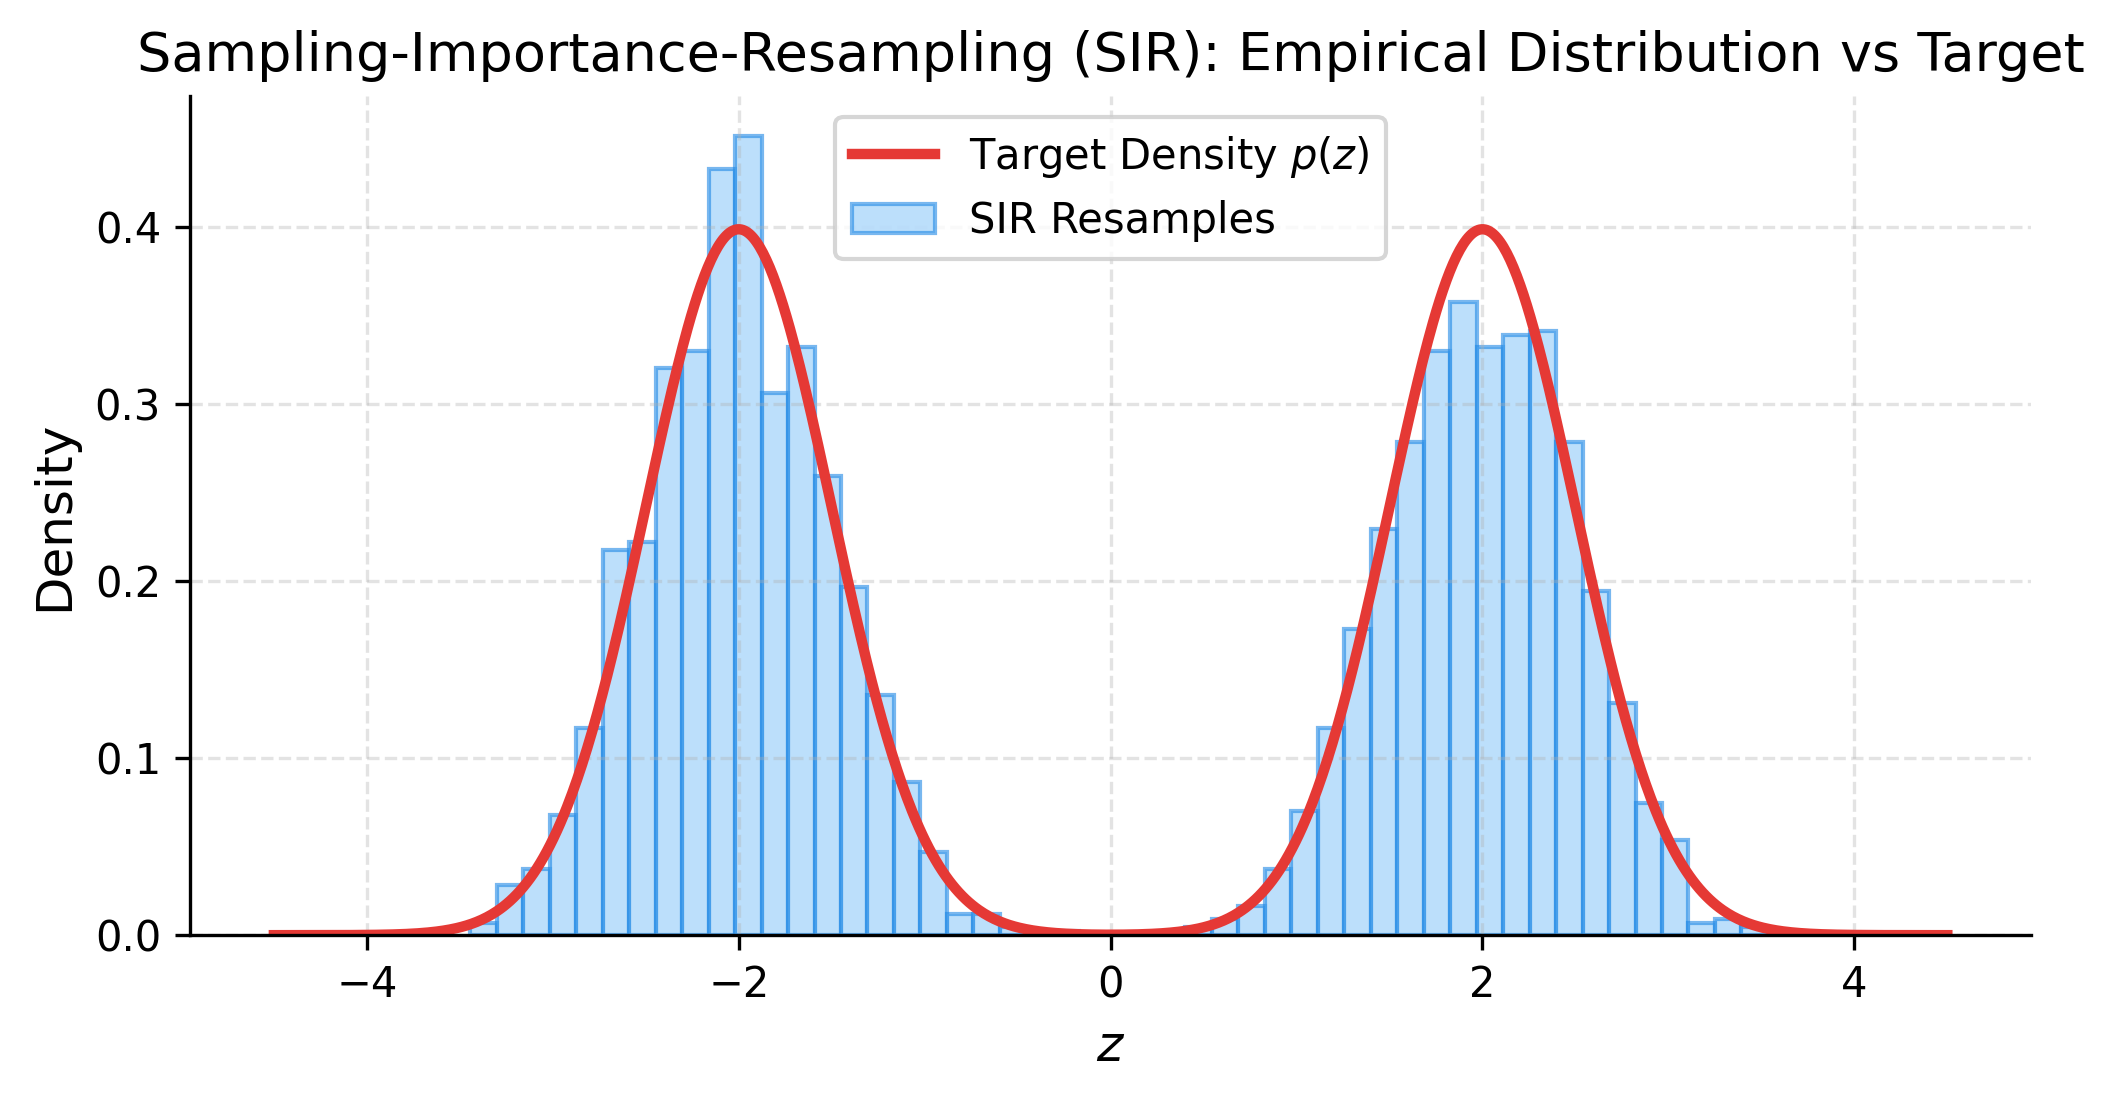

左峰 (z < 0) の割合: 0.5167 (理論値 0.5000)
ユニークなリサンプル数: 2391 / 3000


In [7]:
# SIR の数値検証: 2峰性混合ガウス分布からのサンプリング
target_mix = lambda z: 0.5 * stats.norm.pdf(z, loc=-2.0, scale=0.5) + 0.5 * stats.norm.pdf(z, loc=2.0, scale=0.5)
proposal_broad = lambda z: stats.norm.pdf(z, loc=0.0, scale=2.5)
sample_broad = lambda n, rng: rng.randn(n) * 2.5

sir_res = sampling_importance_resampling(
    target_p=target_mix,
    proposal_q=proposal_broad,
    sample_q=sample_broad,
    num_candidates=15000,
    num_resamples=3000,
    seed=42,
)

fig, ax = plt.subplots(figsize=(7, 3.8), dpi=300)
z_plot = np.linspace(-4.5, 4.5, 1000)
ax.plot(z_plot, target_mix(z_plot), color="#e53935", linewidth=2.5, label="Target Density $p(z)$")
ax.hist(sir_res["resamples"], bins=50, density=True, color="#90caf9", edgecolor="#1e88e5", alpha=0.6, label="SIR Resamples")
ax.set_xlabel("$z$")
ax.set_ylabel("Density")
ax.set_title("Sampling-Importance-Resampling (SIR): Empirical Distribution vs Target")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

prop_left = np.mean(sir_res["resamples"] < 0)
print(f"左峰 (z < 0) の割合: {prop_left:.4f} (理論値 0.5000)")
print(f"ユニークなリサンプル数: {sir_res['num_unique_resamples']} / 3000")
assert abs(prop_left - 0.5) < 0.05, "SIR mixture proportion check failed!"


---

### 第14章 第1節 総括
本節では、確率的推論と生成AIの基盤となる基本サンプリングアルゴリズムを網羅しました：
1. **期待値 (14.1.1)**: モンテカルロ積分の不偏性と $O(1/\sqrt{L})$ 標準誤差（次元の呪いの超越）。
2. **標準分布 (14.1.2)**: 累積分布関数逆関数法、Box-Muller法、円盤棄却サンプリング。
3. **棄却サンプリング (14.1.3)**: 上界定数 $k$、ガンマ分布とコーシー提案分布、正規分布の包絡。
4. **適応的棄却サンプリング (14.1.4)**: 対数凹分布に対する動的包絡線更新と区分的指数提案分布。
5. **重点サンプリング (14.1.5)**: 重点比率推定量と有効サンプルサイズ (ESS)。
6. **重点リサンプリング (14.1.6)**: 重み付き標本から非重み付き標本への変換（SIR）。

次節 **14.2 マルコフ連鎖モンテカルロ法 (Markov Chain Monte Carlo: MCMC)** では、上界定数 $k$ の設定が困難な超高次元空間において、確率的遷移核を用いて定常分布として目的分布を実現するメトロポリス・ヘイスティングス法やギブスサンプリングを探究します。
